# Do senators' stock trades beat the market? 🏛️
### The congress-trading meme vs the disclosed tape — in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Famous_names_beat%3F: Busted](https://img.shields.io/badge/Famous_names_beat%3F-Busted-8b949e?style=flat-square)

Everyone *knows* this one. A famous 2004 academic study (Ziobrowski et al.) found US senators' stock purchases beat the market by about **1% a month** in the 1990s — "senators trade like corporate insiders." Twitter accounts track congressional trades to millions of followers; apps sell copy-trading of politicians' portfolios.

There's just one catch nobody mentions: you can only copy a trade **once it's disclosed** — and by then it's about **three weeks old**. So we tested the only version of the claim that exists for you: buy what a senator bought, the day the disclosure becomes public, and see if it beats the S&P 500.

> 📓 **Plain-language layer.** Want the HAC *t*-stats, the placebo and the clustering autopsy? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Data notes up front.** The tape is the **Senate Stock Watcher** archive — 2,776 disclosed stock purchases by 26 senators, **2015–March 2021** (the scraper stopped there). One senator (David Perdue) is **39%** of it. About 20% of events drop because their ticker no longer exists on Yahoo (**survivorship** — a bias *in favour* of the claim). Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from congress_trading import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PX, SPY, EV = data.load_real()
    ABN = st.event_abnormal(PX, SPY, EV)
else:
    PX = SPY = EV = ABN = None
print("real cache present:", HAVE_REAL,
      "| events:", (0 if EV is None else len(EV)),
      "| tickers:", (0 if PX is None else PX.shape[1]))

# frozen headline numbers (mirror of docs/results.md)
R = {'n_events': 2776, 'n_senators': 26, 'disc_start': '2015-01-05', 'disc_end': '2021-03-09', 'n_R': 1990, 'n_D': 786, 'perdue_share': 39.3, 'famous_n': 1212, 'famous_share': 43.7, 'lag_median': 19, 'lag_mean': 26.3, 'n_tickers': 438, 'n_dropped': 1, 'dropped': 'ITC', 'n_used': 437, 'n_covered': 2221, 'coverage': 80.0, 'bhar': [(63, -0.14, -0.46, 2221), (126, 1.07, 2.33, 2221), (252, 4.87, 6.35, 2221)], 'caltime': [(63, -0.01, -0.0, 1617, 48), (126, 3.72, 1.11, 1680, 80), (252, 2.5, 0.89, 1806, 123)], 'plc_alpha': 3.31, 'plc_alpha_sd': 0.84, 'plc_t': 1.79, 'plc_t_sd': 0.43, 'real_minus_plc': 0.41, 'plc_z': 0.49, 'costs': [(0.0, 3.72, 1.11), (5.0, 3.52, 1.05), (10.0, 3.32, 0.99)], 'splits126': [('R vs D', 1.12, 1553, 0.95, 668, 0.17, 0.18), ('big (>=$15k) vs small', 1.52, 585, 0.91, 1636, 0.6, 0.56), ('famous vs rest', 0.59, 840, 1.36, 1381, -0.77, -0.79)], 'famous252': (9.61, 1.99, 7.61, 4.57), 'famous_ct': (0.09, 0.02), 'boring_ct': (4.66, 1.85), 'exPerdue_ct': (4.75, 1.87), 'syn_null_t': 0.03, 'syn_null_sd': 0.97, 'syn_null_max': 2.1, 'syn_edge_alpha': 27.37, 'syn_edge_t': 12.25, 'fingerprint': '884027dc84c9', 'asof': '2026-07-03'}


real cache present: True | events: 2776 | tickers: 437


## The answer first

| Question | Answer |
|---|---|
| Do senators' disclosed buys beat the market? | **No.** Copy-trading every disclosed purchase earns roughly **0 to +3.7% a year** over the S&P — statistically indistinguishable from zero. |
| But I've seen "+5% in 12 months" headlines? | That number is real — and it's an **illusion**: thousands of overlapping trades re-counting **one** market rally (2020–21). Handle the overlap honestly and it collapses. |
| Is the little drift that remains *their* skill? | **No.** Buying the **same stocks on random dates** earns the same thing (+3.3%/yr). The drift is *which stocks they own*, not *when they trade*. |
| Are the scandal names (Perdue, Loeffler, Inhofe) the alpha? | **No — busted.** Their copy-portfolio earned **+0.09%/yr** over SPY. The famous names are exactly where the nothing is. |

> The 1990s paper may well have been right *for the 1990s, at the senators' own trade dates*. But the thing you can actually do — copy disclosures — has no edge on the modern tape. Modern academic work (Belmont et al. 2022) finds the same.

## 1 · The claim

> *"Senators know things. Committee hearings, briefings, lobbyists. Their personal stock trades beat the market — an academic study proved it. Follow the disclosures and ride along."*

The study is real: **Ziobrowski et al. (2004)**, senators' purchases 1993–1998, ~**85 bps a month** of outperformance. Since the **STOCK Act (2012)** every trade must be disclosed within 30–45 days, which is what makes the copy-trading industry — and this test — possible.

On our tape the median gap between a senator's trade and its public disclosure is **19 days**. That's the product you're being sold: a three-week-old fax.

## 2 · So what?

If the meme is right, it's the cheapest edge in finance — a free, public, legally mandated feed of insider-grade trades. If it's wrong, a lot of people are paying for apps that sell them stale noise. And there's a civic-sized question underneath: the meme is *the* argument in the congressional-stock-ban debate. Whether the disclosed tape actually carries alpha is worth measuring, not assuming.

## 3 · How would we even know?

We take every Senate **P**eriodic **T**ransaction **R**eport in the Senate Stock Watcher archive — **2,776 stock purchases** by **26 senators**, disclosures 2015-01-05 → 2021-03-09 — and for each one we:

1. **Buy at the first market close after the disclosure** (the only date a member of the public could act).
2. **Measure the return vs the S&P 500** (SPY, dividends included on both sides) over the next 3, 6 and 12 months.
3. **Test it two ways** — the naive way (average all trades: *looks* great) and the honest way (a day-by-day portfolio that can't double-count overlapping trades), plus a placebo: the **same stocks bought on random dates**. If the placebo earns the same, the disclosure date carries no information.

## 4 · The teardown — let's actually look

**First, the chart the meme shows you.** Average abnormal return (vs SPY) after each disclosed purchase:

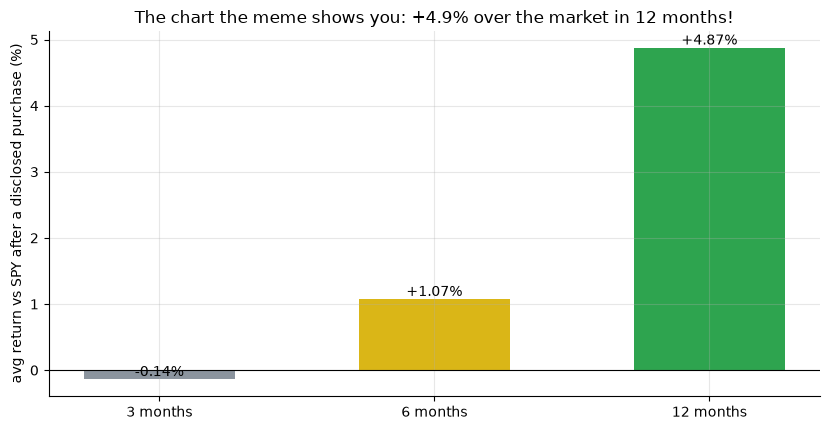

pooled mean abnormal (3/6/12 mo): ['-0.14%', '+1.07%', '+4.87%']


In [2]:
if HAVE_REAL:
    rows = st.pooled_table(ABN)
    means = [r['mean_pct'] for r in rows]
else:
    means = [b[1] for b in R['bhar']]
labels = ['3 months', '6 months', '12 months']
fig, ax = plt.subplots(figsize=(8.4, 4.4))
ax.bar(labels, means, color=[GREY, AMBER, GREEN], width=.55)
for i, v in enumerate(means): ax.annotate(f'{v:+.2f}%', (i, v), ha='center', va='bottom')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('avg return vs SPY after a disclosed purchase (%)')
ax.set_title('The chart the meme shows you: +4.9% over the market in 12 months!')
plt.tight_layout(); plt.show()
print('pooled mean abnormal (3/6/12 mo):', [f'{v:+.2f}%' for v in means])

**+4.87% over the market in a year**, across 2,221 trades — that *looks* like Ziobrowski lives. Here's the problem: those 12-month windows **overlap massively**. One senator filing 300 purchases in 2019–20 gets the same 2020–21 rebound counted 300 times. That's not 2,221 independent bets — it's a handful of market episodes wearing 2,221 costumes.

**The honest version** builds one day-by-day portfolio: every day, hold whatever was disclosed-bought in the last N months, equal-weighted, and compare that single daily series to SPY. No double-counting possible.

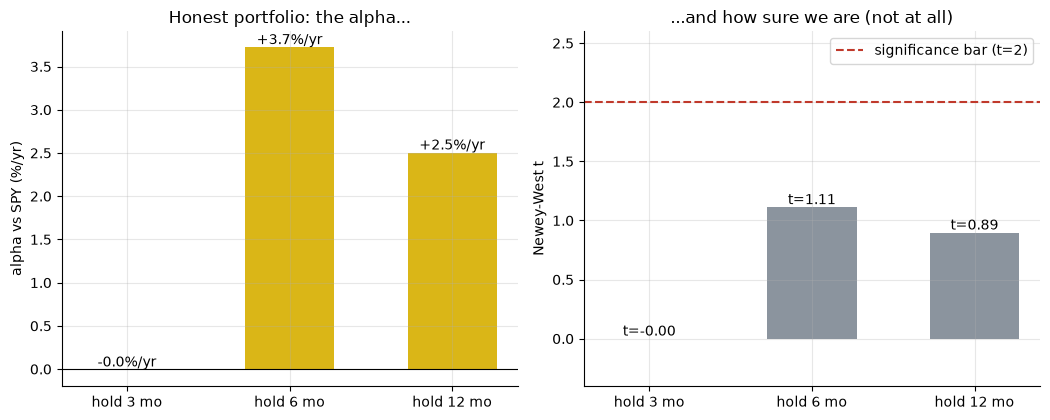

calendar-time: ['-0.01%/yr (t=-0.00)', '+3.72%/yr (t=1.11)', '+2.50%/yr (t=0.89)']


In [3]:
if HAVE_REAL:
    ct = [st.calendar_time(PX, SPY, EV, hold=h) for h in (63, 126, 252)]
    alphas = [r['alpha_ann_pct'] for r in ct]; tvals = [r['nw_t'] for r in ct]
else:
    alphas = [c[1] for c in R['caltime']]; tvals = [c[2] for c in R['caltime']]
labels = ['hold 3 mo', 'hold 6 mo', 'hold 12 mo']
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.6, 4.3))
a1.bar(labels, alphas, color=AMBER, width=.55)
for i, v in enumerate(alphas): a1.annotate(f'{v:+.1f}%/yr', (i, v), ha='center', va='bottom')
a1.axhline(0, c='k', lw=.8); a1.set_ylabel('alpha vs SPY (%/yr)')
a1.set_title('Honest portfolio: the alpha...')
a2.bar(labels, tvals, color=GREY, width=.55)
a2.axhline(2, ls='--', c=RED, label='significance bar (t=2)')
for i, v in enumerate(tvals): a2.annotate(f't={v:.2f}', (i, v), ha='center', va='bottom')
a2.set_ylabel('Newey-West t'); a2.set_ylim(-0.4, 2.6); a2.legend()
a2.set_title('...and how sure we are (not at all)')
plt.tight_layout(); plt.show()
print('calendar-time:', [f'{a:+.2f}%/yr (t={t:.2f})' for a, t in zip(alphas, tvals)])

The +4.9% headline collapses to **+2.5%/yr at t = 0.89** — statistical noise. The best horizon manages **+3.7%/yr at t = 1.11**, still far below the bar.

**And even that drift isn't timing skill.** The killer test: buy the **same stocks** on **random dates** instead of the disclosure dates (20 different random draws):

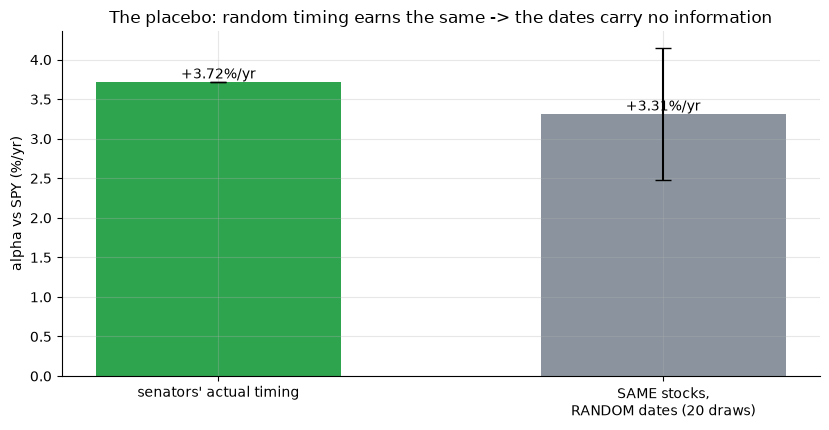

real +3.72%/yr vs placebo +3.31%/yr (sd 0.84)


In [4]:
real_alpha = R['caltime'][1][1]
if HAVE_REAL:
    pl = st.placebo_random_dates(PX, SPY, EV, hold=126, n_seeds=20)
    plc, plc_sd = pl['mean_alpha_ann_pct'], pl['sd_alpha_ann_pct']
    real_alpha = st.calendar_time(PX, SPY, EV, hold=126)['alpha_ann_pct']
else:
    plc, plc_sd = R['plc_alpha'], R['plc_alpha_sd']
fig, ax = plt.subplots(figsize=(8.4, 4.4))
bars = ax.bar(['senators\' actual timing', 'SAME stocks,\nRANDOM dates (20 draws)'],
              [real_alpha, plc], color=[GREEN, GREY], width=.55,
              yerr=[0, plc_sd], capsize=6)
for i, v in enumerate([real_alpha, plc]): ax.annotate(f'{v:+.2f}%/yr', (i, v), ha='center', va='bottom')
ax.set_ylabel('alpha vs SPY (%/yr)')
ax.set_title('The placebo: random timing earns the same -> the dates carry no information')
plt.tight_layout(); plt.show()
print(f'real {real_alpha:+.2f}%/yr vs placebo {plc:+.2f}%/yr (sd {plc_sd:.2f})')

Random dates earn **+3.31%/yr**; the senators' actual dates earn **+3.72%/yr**. Difference: **+0.41%/yr** — well inside the noise. Whatever tiny drift exists comes from *which stocks senators happen to own* (an equal-weight basket of their names beat the cap-weighted S&P in 2015–22 regardless of timing), not from any information in the trades.

**Last hope: the famous names.** Surely Perdue, Loeffler, Inhofe — the senators the DOJ actually investigated in 2020 — are where the edge hides?

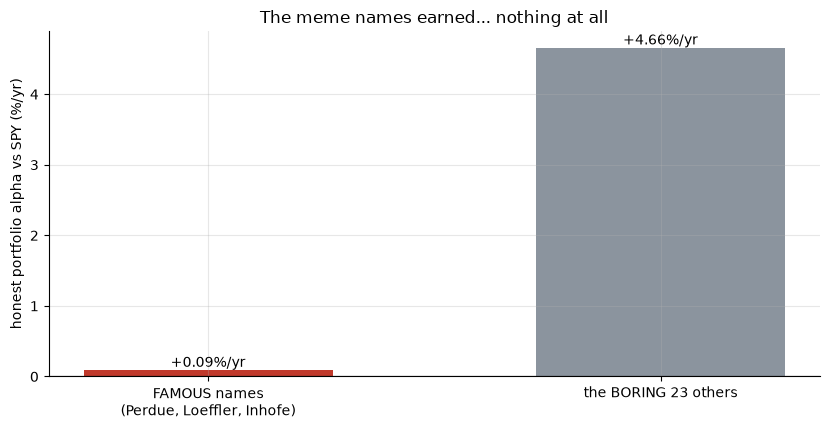

famous +0.09%/yr vs boring +4.66%/yr (neither is significant)


In [5]:
if HAVE_REAL:
    fam = st.calendar_time(PX, SPY, EV[EV['famous']], hold=126)
    bor = st.calendar_time(PX, SPY, EV[~EV['famous']], hold=126)
    fa, ba = fam['alpha_ann_pct'], bor['alpha_ann_pct']
else:
    fa, ba = R['famous_ct'][0], R['boring_ct'][0]
fig, ax = plt.subplots(figsize=(8.4, 4.4))
ax.bar(['FAMOUS names\n(Perdue, Loeffler, Inhofe)', 'the BORING 23 others'],
       [fa, ba], color=[RED, GREY], width=.55)
for i, v in enumerate([fa, ba]): ax.annotate(f'{v:+.2f}%/yr', (i, v), ha='center', va='bottom')
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('honest portfolio alpha vs SPY (%/yr)')
ax.set_title('The meme names earned... nothing at all')
plt.tight_layout(); plt.show()
print(f'famous {fa:+.2f}%/yr vs boring {ba:+.2f}%/yr (neither is significant)')

The famous names: **+0.09%/yr** — as close to exactly zero as markets get. The boring rest: +4.66%/yr (still not significant, t = 1.85). The meme has it exactly backwards: what little drift exists lives with the senators nobody tweets about.

## 5 · The verdict

- **Signal — None.** The copy-trade earns 0 to +3.7%/yr over SPY with *t* ≤ 1.11 — noise — and the random-dates placebo shows the dates carry no information anyway. The famous +4.9%/12-mo pooled number is overlap double-counting.
- **Tradability — Mirage.** You'd be trading 19-day-old news with zero measurable edge, on a tape that's *survivor-tilted in the claim's favour* and still says no.
- **"The famous names are the alpha"? — Busted.** Perdue/Loeffler/Inhofe's copy-portfolio: +0.09%/yr. The scandal is political, not statistical.

> Ziobrowski measured senators at their **own trade dates** in the 1990s. We measured what **you** can do — and the modern disclosed tape agrees with the modern papers: nothing there.

## 6 · Going further 🚪

- **This is the Senate, 2015–2021.** The archive stops in March 2021 — the Tuberville era and the House (Pelosi, the biggest meme of all) are out of scope by data, not by choice. House PTRs exist (House Stock Watcher, Quiver) if you want to extend the test.
- **Purchases only.** Sales are harder to interpret (liquidity, divorce, diversification). Richard Burr's infamous February 2020 dump is a *sale* story — a different study.
- **Survivorship works for the meme here.** A fifth of the disclosed buys point at tickers that later died or were absorbed; they're missing from Yahoo and from our panel. Adding them back would likely make the copy-trade look *worse*.
- **The sibling study.** [Corporate insiders (Form 4)](../../263-insider-buying/) — people trading their *own* company — is the version of this claim with actual legal teeth and a much longer literature.

*Think the edge is in the House, in options, or in committee-matched trades? The engine is three files — swap the event table and show us a calendar-time t over 2.*